# Notebook 01 — Análisis Exploratorio de Datos (EDA)
**Proyecto:** Sistema Multi-Agente para Análisis de Deserción Estudiantil  
**Dataset:** Predict Students'Dropout and Academic Success  
**Fuente:** Kaggle — https://www.kaggle.com/datasets/ankushpanday1/predict-students-dropout-and-academic-success  
*(también disponible en UCI ML Repository id=697 — descargado automáticamente vía `ucimlrepo`)*  
**Variable objetivo:** `Target` → binarizada como `Dropout` (1) vs `No Dropout` (0)

---
## Objetivos de este notebook
1. Cargar el dataset desde UCI y guardarlo en `data/raw/`
2. Explorar la distribución de la variable objetivo
3. Analizar valores nulos y outliers
4. Generar mínimo 4 visualizaciones informativas
5. Documentar hallazgos que motivarán decisiones en el notebook de modelado

In [25]:
# ── Importaciones ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.dpi': 120})

# Rutas relativas al notebook
RAW_PATH = '../data/raw/student_dropout.csv'
FIGURES_PATH = '../docs/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga del dataset
Usamos `ucimlrepo` para descargar directamente el dataset. Si ya existe en `data/raw/`, lo cargamos desde disco para no repetir la descarga.

In [26]:
def cargar_dataset(ruta_cache: str) -> pd.DataFrame:
    """Carga el dataset desde caché local o lo descarga de UCI si no existe."""
    if os.path.exists(ruta_cache):
        print(f'Cargando desde caché: {ruta_cache}')
        return pd.read_csv(ruta_cache)

    print('Descargando dataset desde UCI ML Repository (id=697)...')
    repo = fetch_ucirepo(id=697)
    X = repo.data.features
    y = repo.data.targets
    df = pd.concat([X, y], axis=1)
    df.to_csv(ruta_cache, index=False)
    print(f'Dataset guardado en: {ruta_cache}')
    return df


df = cargar_dataset(RAW_PATH)
print(f'\nForma del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Cargando desde caché: ../data/raw/student_dropout.csv

Forma del dataset: 4424 filas × 37 columnas


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Revisión general del dataset

In [27]:
print('=== Tipos de datos ===')
print(df.dtypes.value_counts())
print('\n=== Resumen estadístico ===')
df.describe().T

=== Tipos de datos ===
int64      29
float64     7
object      1
Name: count, dtype: int64

=== Resumen estadístico ===


,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


## 3. Variable objetivo: distribución de clases

El dataset original tiene 3 clases: `Dropout`, `Enrolled`, `Graduate`.  
Para este proyecto la convertimos en **clasificación binaria**:  
- `1` = Dropout (desertor)
- `0` = No Dropout (matriculado o graduado)

**Justificación:** La pregunta de investigación se enfoca en identificar estudiantes en riesgo de deserción antes de que ocurra.

In [28]:
# Binarizar variable objetivo
df['Dropout'] = (df['Target'] == 'Dropout').astype(int)

print('Distribución original de Target:')
print(df['Target'].value_counts())
print('\nDistribución binaria (Dropout):')
print(df['Dropout'].value_counts())

tasa_desercion = df['Dropout'].mean() * 100
print(f'\nTasa de deserción: {tasa_desercion:.1f}%')

if tasa_desercion < 40 or tasa_desercion > 60:
    print('⚠ Dataset desbalanceado — usar F1, AUC-ROC en lugar de accuracy.')

Distribución original de Target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Distribución binaria (Dropout):
Dropout
0    3003
1    1421
Name: count, dtype: int64

Tasa de deserción: 32.1%
⚠ Dataset desbalanceado — usar F1, AUC-ROC en lugar de accuracy.


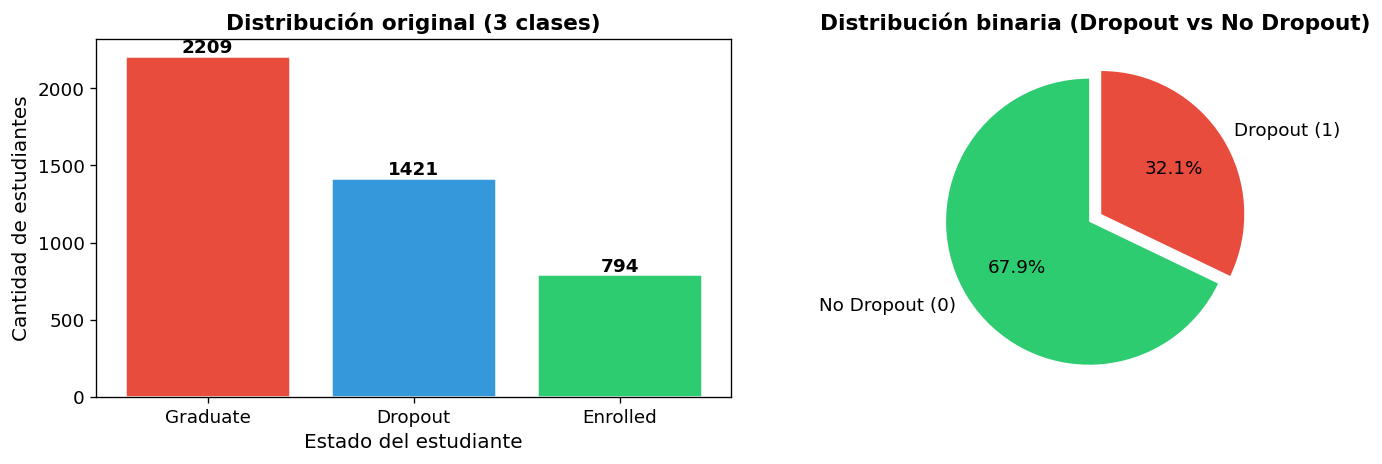

Fig 1 guardada en docs/figures/


In [29]:
# ── Visualización 1: Distribución de la variable objetivo ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución original (3 clases)
conteos_orig = df['Target'].value_counts()
colores_orig = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(conteos_orig.index, conteos_orig.values, color=colores_orig, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución original (3 clases)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Estado del estudiante')
axes[0].set_ylabel('Cantidad de estudiantes')
for i, v in enumerate(conteos_orig.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Distribución binaria
conteos_bin = df['Dropout'].value_counts()
etiquetas = ['No Dropout (0)', 'Dropout (1)']
colores_bin = ['#2ecc71', '#e74c3c']
axes[1].pie(
    conteos_bin.values,
    labels=[etiquetas[i] for i in conteos_bin.index],
    colors=[colores_bin[i] for i in conteos_bin.index],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05, 0.05]
)
axes[1].set_title('Distribución binaria (Dropout vs No Dropout)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}01_distribucion_objetivo.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig 1 guardada en docs/figures/')

## 4. Análisis de valores nulos

In [30]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('porcentaje', ascending=False)

if len(resumen_nulos) == 0:
    print('No hay valores nulos en el dataset.')
else:
    print(f'Columnas con valores nulos ({len(resumen_nulos)}):')
    print(resumen_nulos)
    print('\nEstrategia: imputar con mediana (numéricas) / moda (categóricas) en el notebook 02.')

No hay valores nulos en el dataset.


## 5. Análisis de outliers con IQR

In [31]:
def detectar_outliers_iqr(df: pd.DataFrame, columnas: list) -> pd.DataFrame:
    """Detecta outliers usando el método IQR para cada columna numérica."""
    resultados = []
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        n_outliers = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
        pct = (n_outliers / len(df)) * 100
        resultados.append({'columna': col, 'n_outliers': n_outliers, 'porcentaje': round(pct, 2)})
    return pd.DataFrame(resultados).sort_values('n_outliers', ascending=False)


cols_numericas = df.select_dtypes(include=[np.number]).columns.drop('Dropout').tolist()
reporte_outliers = detectar_outliers_iqr(df, cols_numericas)
print('Top 10 columnas con más outliers:')
print(reporte_outliers.head(10).to_string(index=False))

Top 10 columnas con más outliers:
                            columna  n_outliers  porcentaje
                 Scholarship holder        1099       24.84
   Curricular units 2nd sem (grade)         877       19.82
   Curricular units 1st sem (grade)         726       16.41
             Previous qualification         707       15.98
Curricular units 1st sem (credited)         577       13.04
                  Application order         541       12.23
Curricular units 2nd sem (credited)         530       11.98
            Tuition fees up to date         528       11.93
                     Marital Status         505       11.42
                             Debtor         503       11.37


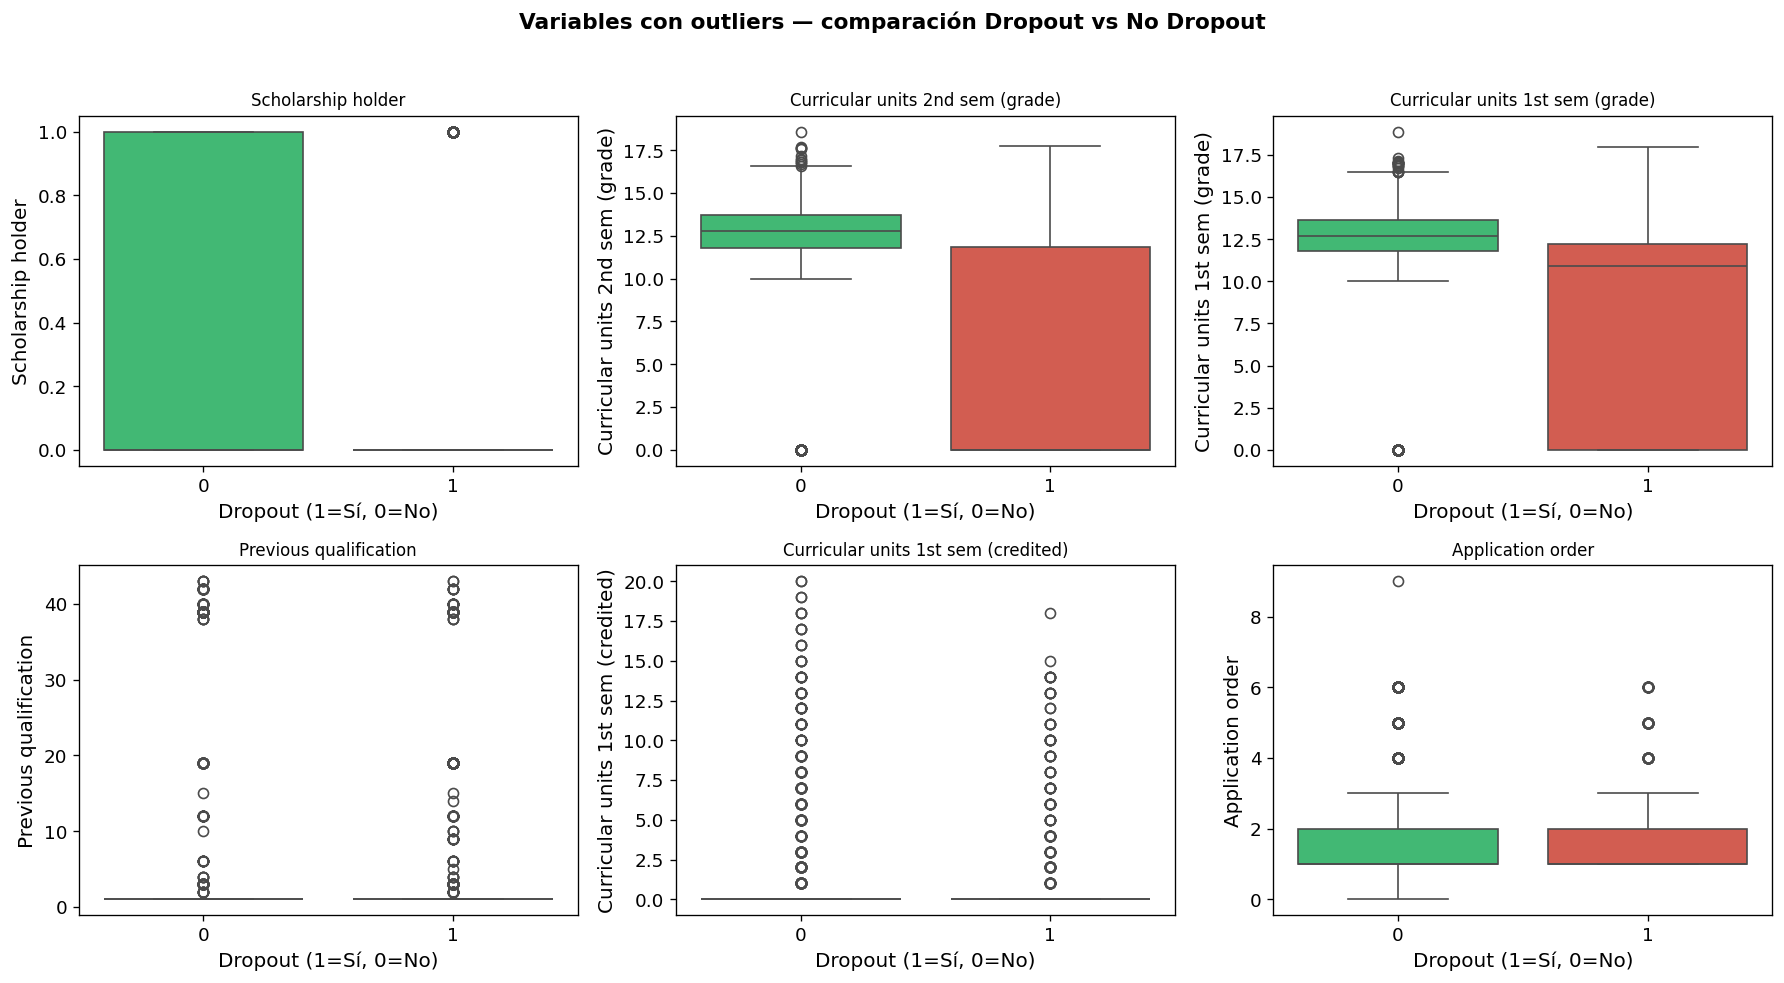

Fig 2 guardada.


In [32]:
# ── Visualización 2: Boxplots de variables con más outliers ────────────────
top_outliers = reporte_outliers[reporte_outliers['n_outliers'] > 0].head(6)['columna'].tolist()

if top_outliers:
    n_cols = min(3, len(top_outliers))
    n_rows = (len(top_outliers) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(top_outliers):
        sns.boxplot(x='Dropout', y=col, data=df, ax=axes[i],
                    palette={'0': '#2ecc71', '1': '#e74c3c'})
        axes[i].set_title(f'{col}', fontsize=10)
        axes[i].set_xlabel('Dropout (1=Sí, 0=No)')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Variables con outliers — comparación Dropout vs No Dropout',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_PATH}02_boxplots_outliers.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Fig 2 guardada.')
else:
    print('No se detectaron outliers significativos.')

## 6. Análisis de variables académicas clave

Las unidades curriculares del 1er y 2do semestre son las variables más predictivas en la literatura. Comparamos estudiantes que desertaron vs los que no.

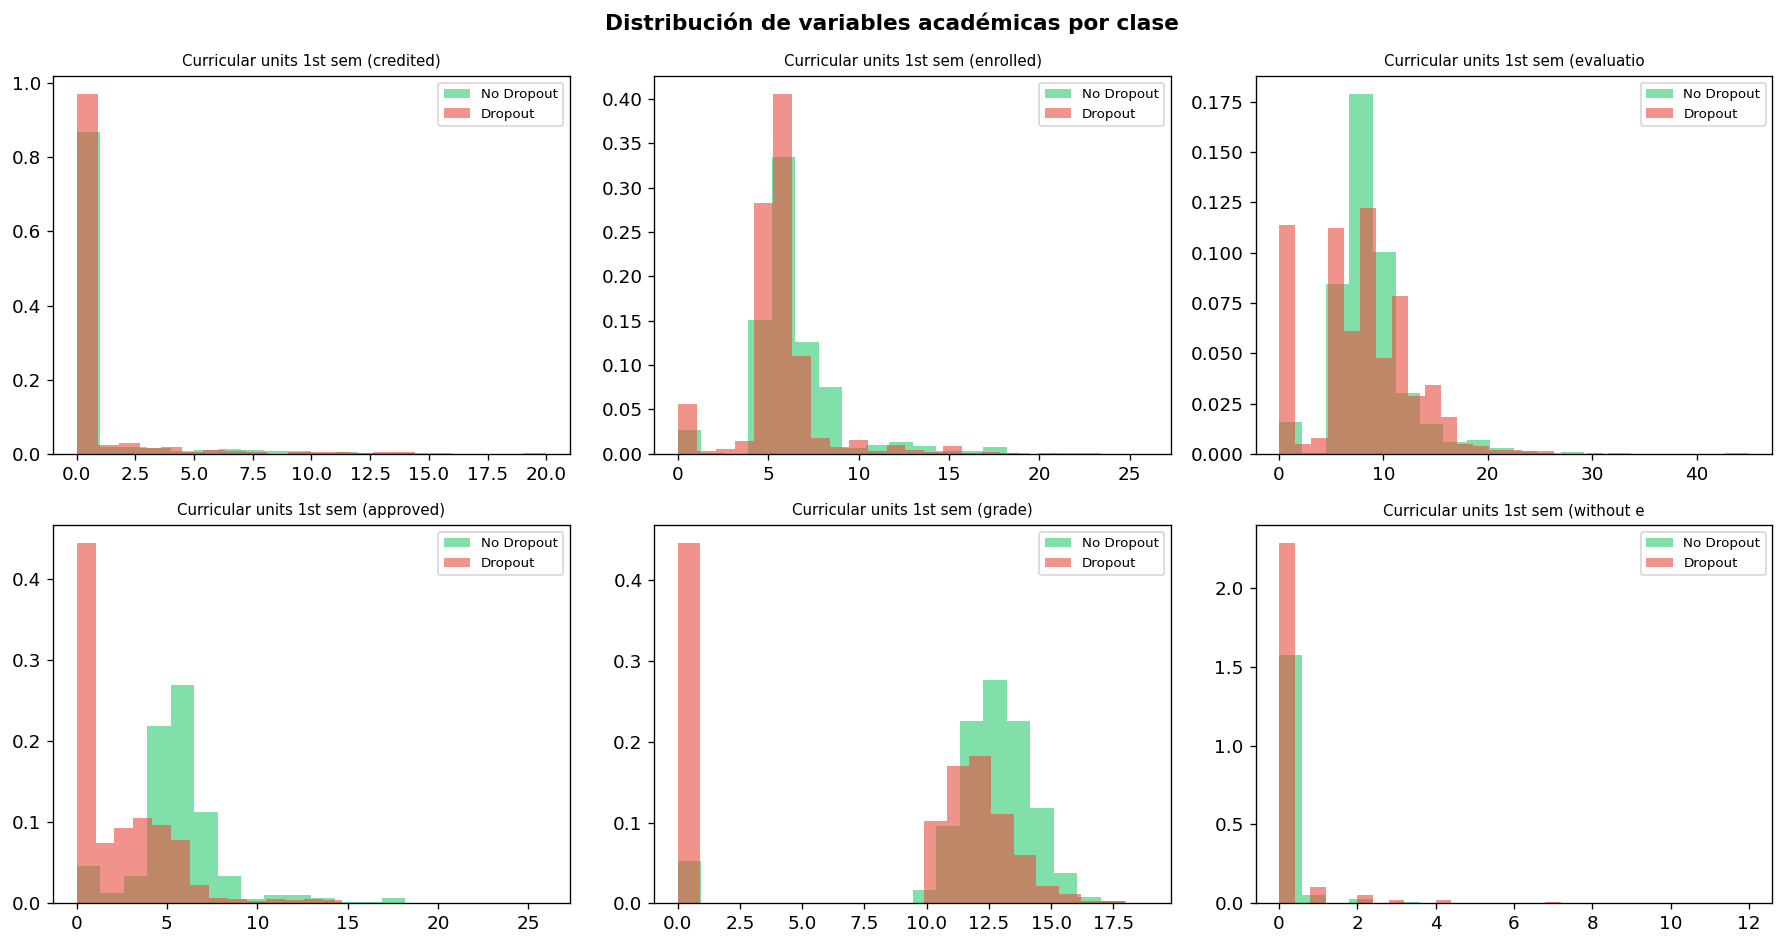

Fig 3 guardada.


In [33]:
# ── Visualización 3: Variables académicas del 1er semestre ────────────────
# Identificamos columnas del 1er semestre
cols_1sem = [c for c in df.columns if '1st' in c or '1_sem' in c.lower()]
cols_1sem_num = [c for c in cols_1sem if df[c].dtype in [np.float64, np.int64]]

if not cols_1sem_num:
    # Fallback: usamos columnas numéricas con alta correlación con Dropout
    corr_con_target = df[cols_numericas + ['Dropout']].corr()['Dropout'].abs()
    cols_1sem_num = corr_con_target.drop('Dropout').nlargest(6).index.tolist()

cols_plot = cols_1sem_num[:6]
n_cols = min(3, len(cols_plot))
n_rows = (len(cols_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(cols_plot):
    df_no_drop = df[df['Dropout'] == 0][col]
    df_drop = df[df['Dropout'] == 1][col]
    axes[i].hist(df_no_drop, bins=20, alpha=0.6, color='#2ecc71', label='No Dropout', density=True)
    axes[i].hist(df_drop, bins=20, alpha=0.6, color='#e74c3c', label='Dropout', density=True)
    axes[i].set_title(col[:35], fontsize=9)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de variables académicas por clase',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}03_variables_academicas.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig 3 guardada.')

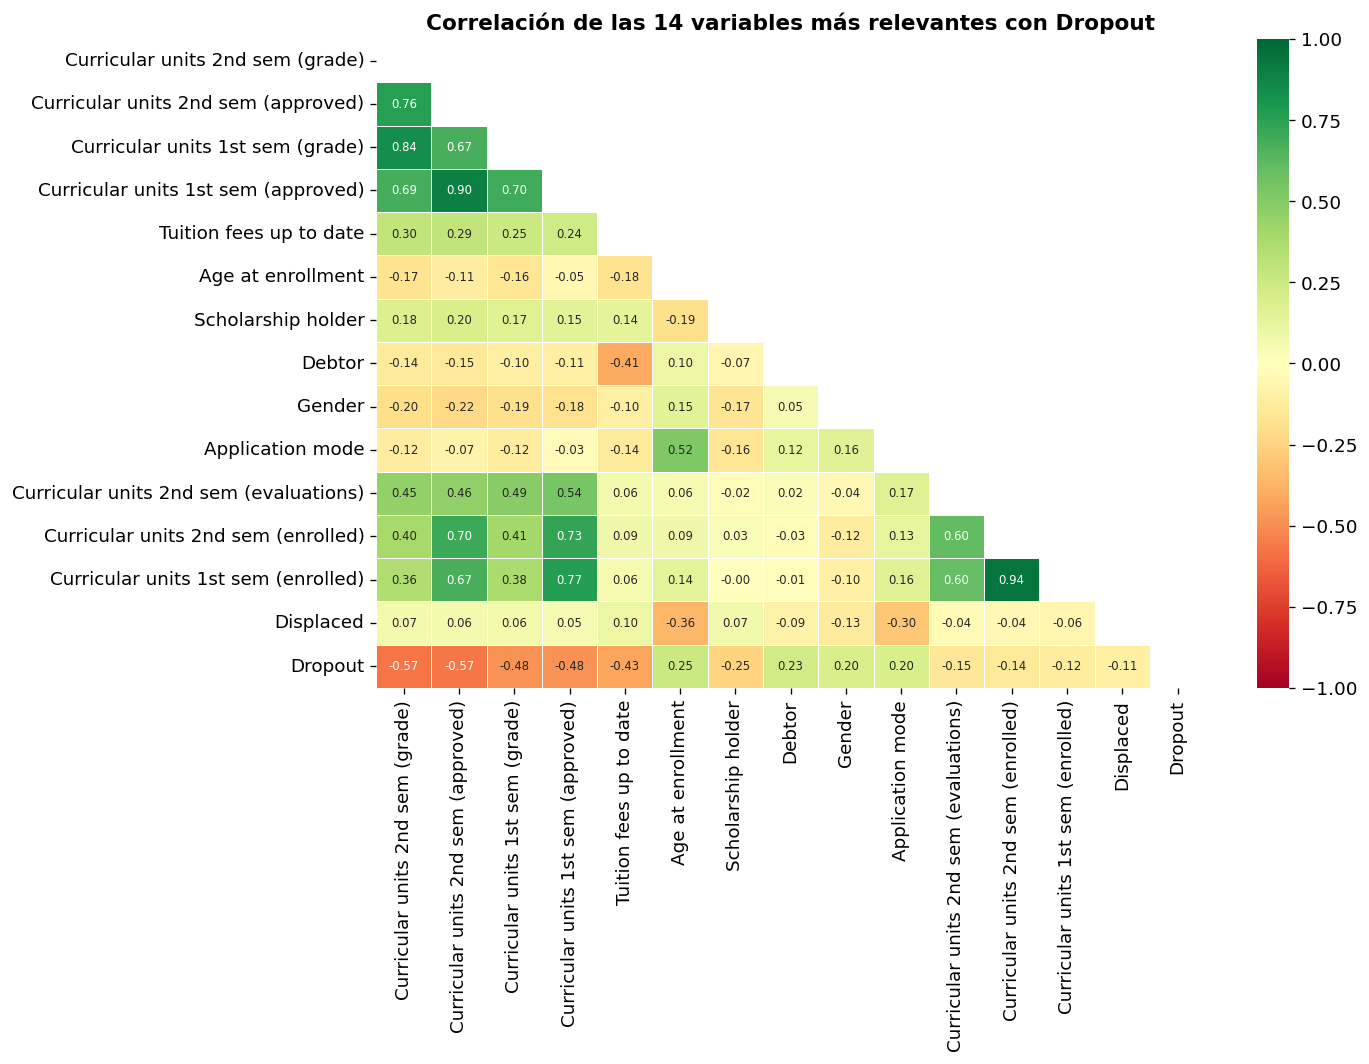

Fig 4 guardada.


In [34]:
# ── Visualización 4: Matriz de correlación ─────────────────────────────────
# Tomamos las 15 variables con mayor correlación absoluta con Dropout
corr_matrix = df[cols_numericas + ['Dropout']].corr()
top_corr_cols = corr_matrix['Dropout'].abs().drop('Dropout').nlargest(14).index.tolist()
cols_heatmap = top_corr_cols + ['Dropout']

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix.loc[cols_heatmap, cols_heatmap], dtype=bool))
sns.heatmap(
    corr_matrix.loc[cols_heatmap, cols_heatmap],
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Correlación de las 14 variables más relevantes con Dropout',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}04_correlacion.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig 4 guardada.')

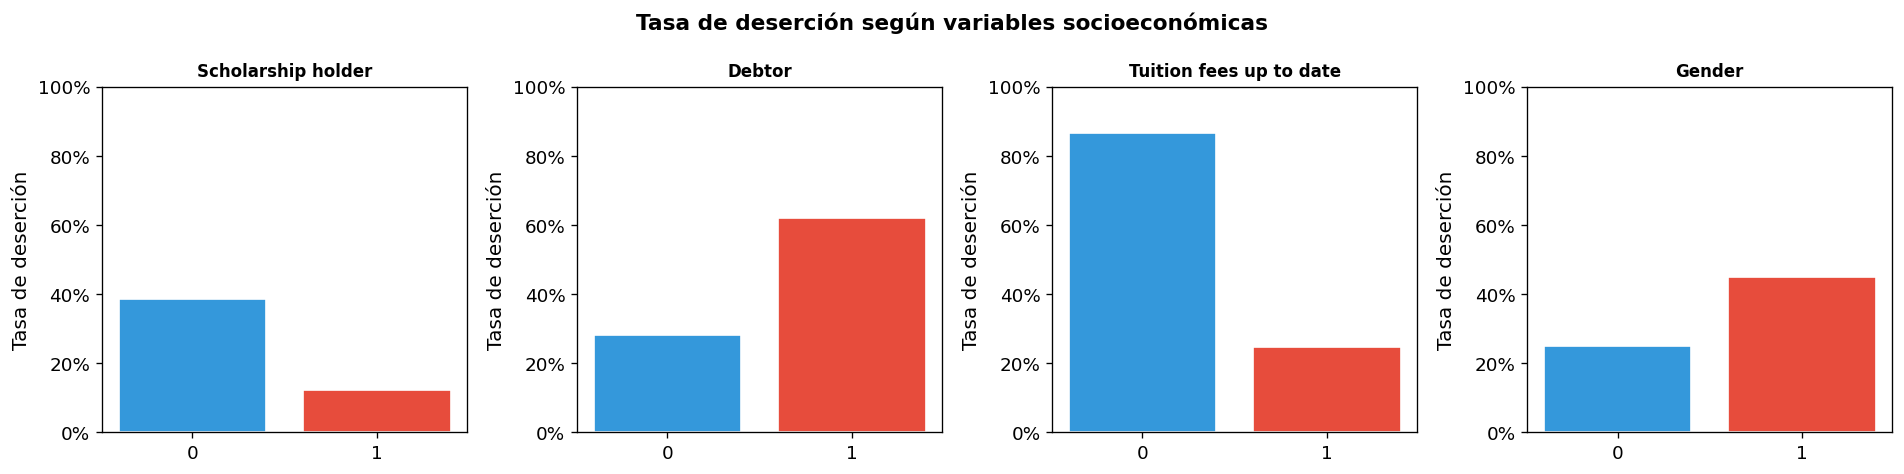

Fig 5 guardada.


In [35]:
# ── Visualización 5: Variables socioeconómicas vs Dropout ─────────────────
# Scholarship holder, Debtor, Tuition fees up to date
vars_socioec = []
for candidato in ['Scholarship holder', 'Debtor', 'Tuition fees up to date',
                   'Gender', 'Displaced', 'International']:
    match = [c for c in df.columns if candidato.lower() in c.lower()]
    if match:
        vars_socioec.append(match[0])

vars_socioec = vars_socioec[:4]  # máximo 4 para que quede limpio

if vars_socioec:
    fig, axes = plt.subplots(1, len(vars_socioec), figsize=(4 * len(vars_socioec), 4))
    if len(vars_socioec) == 1:
        axes = [axes]

    for i, col in enumerate(vars_socioec):
        tasa = df.groupby(col)['Dropout'].mean().reset_index()
        axes[i].bar(tasa[col].astype(str), tasa['Dropout'],
                    color=['#3498db', '#e74c3c'][:len(tasa)], edgecolor='white')
        axes[i].set_title(col[:25], fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Tasa de deserción')
        axes[i].set_ylim(0, 1)
        axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

    fig.suptitle('Tasa de deserción según variables socioeconómicas',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{FIGURES_PATH}05_socioeconomicas.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Fig 5 guardada.')

## 7. Resumen de hallazgos EDA

> Completar esta celda con las observaciones encontradas después de ejecutar el notebook.

In [36]:
print('=== RESUMEN EDA ===')
print(f'Total de estudiantes:        {len(df)}')
print(f'Total de variables:          {len(df.columns) - 2}  (sin Target ni Dropout)')
print(f'Tasa de deserción:           {df["Dropout"].mean()*100:.1f}%')
print(f'Valores nulos:               {df.isnull().sum().sum()}')
print(f'Variables con outliers:      {(reporte_outliers["n_outliers"] > 0).sum()}')

print('\n--- Top 5 variables más correlacionadas con Dropout ---')
top5 = corr_matrix['Dropout'].abs().drop('Dropout').nlargest(5)
for col, val in top5.items():
    signo = '+' if corr_matrix['Dropout'][col] > 0 else '-'
    print(f'  {signo}{val:.3f}  {col}')

print('\n--- Decisiones de diseño para el modelado (notebook 03) ---')
print('  1. Métrica principal: F1-score y AUC-ROC (dataset desbalanceado)')
print('  2. Considerar SMOTE o class_weight para balancear clases')
print('  3. Features académicas del 1er semestre serán las más predictivas')
print('  4. Normalización con StandardScaler dentro del pipeline (evita leakage)')

=== RESUMEN EDA ===
Total de estudiantes:        4424
Total de variables:          36  (sin Target ni Dropout)
Tasa de deserción:           32.1%
Valores nulos:               0
Variables con outliers:      28

--- Top 5 variables más correlacionadas con Dropout ---
  -0.572  Curricular units 2nd sem (grade)
  -0.570  Curricular units 2nd sem (approved)
  -0.481  Curricular units 1st sem (grade)
  -0.479  Curricular units 1st sem (approved)
  -0.429  Tuition fees up to date

--- Decisiones de diseño para el modelado (notebook 03) ---
  1. Métrica principal: F1-score y AUC-ROC (dataset desbalanceado)
  2. Considerar SMOTE o class_weight para balancear clases
  3. Features académicas del 1er semestre serán las más predictivas
  4. Normalización con StandardScaler dentro del pipeline (evita leakage)


---
**Próximo paso:** `02_preprocessing.ipynb` — limpieza, feature engineering y split train/val/test.